#**Project One**

##**Description + Question**

**Course data will be collected from California State University Northridge, focusing on the amount of course listings per the multiple departments.**

**Key attributes I will be looking for are course titles and departments to analyze number of courses per department and most to least offered subjects.**

**Those who would be interested in this data are students who are interested in understanding when courses are typically offered so they can plan their schedules to fit their needs and avoid conflicts. Academic advisors can also use this information to guide students in creating a balance in their schedules. Admin may also benefit from this data to see the patterns in course scheduling to better resource allocation and make class offerings better accross departments.**

**This dataset is important because it provides insight into course scheduling patterns. Specifically allowing analysis of how courses are distributed across different days of the week and times of day, how it varies between departments, and how class availability is structured throughout the week. This can improve scheduling efficiency and student success.**

**Question - How are courses distributed across different days of the week and times of day across departments at California State University Northridge?**

#**California State University, Northridge Course Listings**

Sources: https://catalog.csun.edu/course-directory/

##Fetching CSUN Catalog

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
import requests
from bs4 import BeautifulSoup
import time

csun_base_url = "https://catalog.csun.edu/course-directory/"

def fetch_csun_page(url):
    """
    Fetches a page from CSUN catalog.
    """
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/123.0.0.0 Safari/537.36'
    }

    try:
        response = requests.get(url, headers=headers)
        response.raise_for_status()
        return BeautifulSoup(response.text, 'html.parser')
    except requests.exceptions.RequestException as e:
        print(f"Error fetching page: {e}")
        return None

print("Setup complete. You can now use `fetch_csun_page` to get course listings.")

Setup complete. You can now use `fetch_csun_page` to get course listings.


In [5]:
csun_soup = fetch_csun_page(csun_base_url)

if csun_soup:
    print("Successfully fetched CSUN course directory page.")
else:
    print("Failed to fetch CSUN course directory page.")

Successfully fetched CSUN course directory page.


**This code allowed me to retrieve the HTML content of CSUN's course directory webpage and parsed it for more data to be extracted.**

## Data Cleaning and Validation

In [7]:
department_links = []

for link in csun_soup.find_all('a', href=True):
    href = link['href']
    if href.startswith('https://catalog.csun.edu/academics/') and href.endswith('/courses'):
        department_links.append(href)

department_links = list(set(department_links))

print(f"Found {len(department_links)} unique department course links.")
print("Example department links:")
for i, link in enumerate(department_links[:10]):
    print(link)

Found 113 unique department course links.
Example department links:
https://catalog.csun.edu/academics/MUS/courses
https://catalog.csun.edu/academics/MEIS/courses
https://catalog.csun.edu/academics/CPLX/courses
https://catalog.csun.edu/academics/INDS/courses
https://catalog.csun.edu/academics/CHEM/courses
https://catalog.csun.edu/academics/MKT-misc/courses
https://catalog.csun.edu/academics/ARMN/courses
https://catalog.csun.edu/academics/FREN/courses
https://catalog.csun.edu/academics/ELPS/courses
https://catalog.csun.edu/academics/ASTR/courses


**In my data cleaning and validation I first had to extract the links to the individual department course pages from the fetched CSUN course directory.I then printed the total number of unique department course links which was 113 and confirming that the extraction was a success. I only displayed 10 links to be sure they were valid from the catalog page.**

**It wasn't difficult to fetch and extract data because it has consistent formatting and does not have anti-scraping protections the way indeed did. When I first tried indeed, I kept getting blocked from scraping it so I could not even move past this code. I was not successful with indeed because of their anti-scraping protections which I should've seen coming since it is a big company.**

In [8]:
import re

def parse_department_page(url):
    """
    Fetches a department page and extracts course information (titles) and sets scheduling info to N/A.
    """
    print(f"Fetching: {url}")
    soup = fetch_csun_page(url)
    if not soup:
        return []

    courses_data = []
    department_name = url.split('/')[-2]

    course_items = soup.find_all('div', class_=re.compile(r'inner-item'))

    for item in course_items:
        course_title_tag = item.find('h3', class_='csun-subhead')
        if course_title_tag:
            course_title = course_title_tag.get_text(strip=True)

        courses_data.append({
            'department': department_name,
            'course_title': course_title
        })

    return courses_data

all_courses = []
for link in department_links:
    all_courses.extend(parse_department_page(link))
    time.sleep(1)

courses_df = pd.DataFrame(all_courses)

print(f"Total courses found: {len(courses_df)}")
print("Extracted courses:")
print(courses_df.head())

Fetching: https://catalog.csun.edu/academics/MUS/courses
Fetching: https://catalog.csun.edu/academics/MEIS/courses
Fetching: https://catalog.csun.edu/academics/CPLX/courses
Fetching: https://catalog.csun.edu/academics/INDS/courses
Fetching: https://catalog.csun.edu/academics/CHEM/courses
Fetching: https://catalog.csun.edu/academics/MKT-misc/courses
Fetching: https://catalog.csun.edu/academics/ARMN/courses
Fetching: https://catalog.csun.edu/academics/FREN/courses
Fetching: https://catalog.csun.edu/academics/ELPS/courses
Fetching: https://catalog.csun.edu/academics/ASTR/courses
Fetching: https://catalog.csun.edu/academics/SUST/courses
Fetching: https://catalog.csun.edu/academics/CLAS/courses
Fetching: https://catalog.csun.edu/academics/CM/courses
Fetching: https://catalog.csun.edu/academics/ENGL/courses
Fetching: https://catalog.csun.edu/academics/PERS/courses
Fetching: https://catalog.csun.edu/academics/CECS-misc/courses
Fetching: https://catalog.csun.edu/academics/ARAB/courses
Fetching

**The extraction for course titles begins here and it extracts from each CSUN department webpage. This fetches the page, parses through the HTML, and located the course enries by finding the specific div element. For courses, it specifically finds the h3 tage and stores it along with the department name in the list. Then a list of all the links get printed. Here we found that there are 4508 courses.**

In [19]:
print(f"Initial number of courses: {len(courses_df)}")

courses_df_cleaned = courses_df.drop_duplicates().copy()

print(f"Number of courses after removing duplicates: {len(courses_df_cleaned)}")
print(f"Number of duplicate courses removed: {len(courses_df) - len(courses_df_cleaned)}")

courses_df = courses_df_cleaned

Initial number of courses: 4395
Number of courses after removing duplicates: 4395
Number of duplicate courses removed: 0


**I checked to see if there were any duplicates, there were 0 which can be expected considering this is a University website that shouldn't have double of the same course name.**

In [20]:
course_title_pattern = r"^([A-Z]{2,6})\s?([0-9A-Z]{3,5})(?:[A-Z]-[A-Z])?(?:\.\s?)(.*)"

courses_df['is_title_valid'] = courses_df['course_title'].str.contains(course_title_pattern, na=False, regex=True)

invalid_titles = courses_df[~courses_df['is_title_valid']]

print(f"\nNumber of course titles matching expected format: {courses_df['is_title_valid'].sum()}")
print(f"Number of course titles NOT matching expected format: {len(invalid_titles)}")

if not invalid_titles.empty:
    print("\nSample of course titles NOT matching the typical format (first 10):\n")
    display(invalid_titles.head(10)[['department', 'course_title']])
else:
    print("\nAll course titles appear to follow the typical format.")


Number of course titles matching expected format: 3895
Number of course titles NOT matching expected format: 500

Sample of course titles NOT matching the typical format (first 10):



/tmp/ipykernel_7531/111629242.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  courses_df['is_title_valid'] = courses_df['course_title'].str.contains(course_title_pattern, na=False, regex=True)


,department,course_title
6,MUS,MUS 111/L. Musicianship I and Lab (1/1)
7,MUS,MUS 112/L. Musicianship II and Lab (1/1)
8,MUS,MUS 120/L. Arts Immersion: Music and Lab (1/1)
14,MUS,"MUS 140-159A,B. Individual Lessons (1-1, 2-2)"
27,MUS,MUS 191/L. Fundamentals of Music Technology an...
34,MUS,MUS 211/L. Musicianship III and Lab (1/1)
35,MUS,MUS 212/L. Musicianship IV and Lab (1/1)
44,MUS,"MUS 240-259A,B. Individual Lessons (1-1, 2-2)"
49,MUS,MUS 293/L. Field Experience in Music Industry ...
59,MUS,MUS 311/L. Musicianship V and Lab (1/1)


**The code above is validating course title formats. This was done using a pattern that shows and checks the standard format that CSUN uses. An example of their standard format is 'ATE 698. Graduate Project (3)'. This format is Department name, 3 digit number ending in a period (XXX.), along with the course title, and the amount of credits it is.**

**According to the data extracted, the majority of the course titles matched the expected format (3,895) but 500 course titles did not match the expected format. This is due to having additional formatting after the course numbers. For example, we can see the list printed of those courses that did not match the pattern, MUS (Music) being the main one had MUS 111/L. or MUS 140-159,B.**

##Insights

Number of Courses per Department:

| department   | count   |
|:-------------|:--------|
| MUS          | 202     |
| ART          | 160     |
| KIN-misc     | 158     |
| FCS          | 132     |
| HIST         | 126     |
| HSCI         | 126     |
| ENGL         | 121     |
| EPC          | 112     |
| BIOL         | 111     |
| ECE          | 99      |


| department   | count   |
|:-------------|:--------|
| ARAB         | 2       |
| ATHL         | 2       |
| KOR          | 2       |
| HEBR         | 2       |
| MEIS         | 1       |
| HUMN         | 1       |
| SBS          | 1       |
| PHSC         | 1       |
| LEAD         | 1       |
| LIB          | 1       |


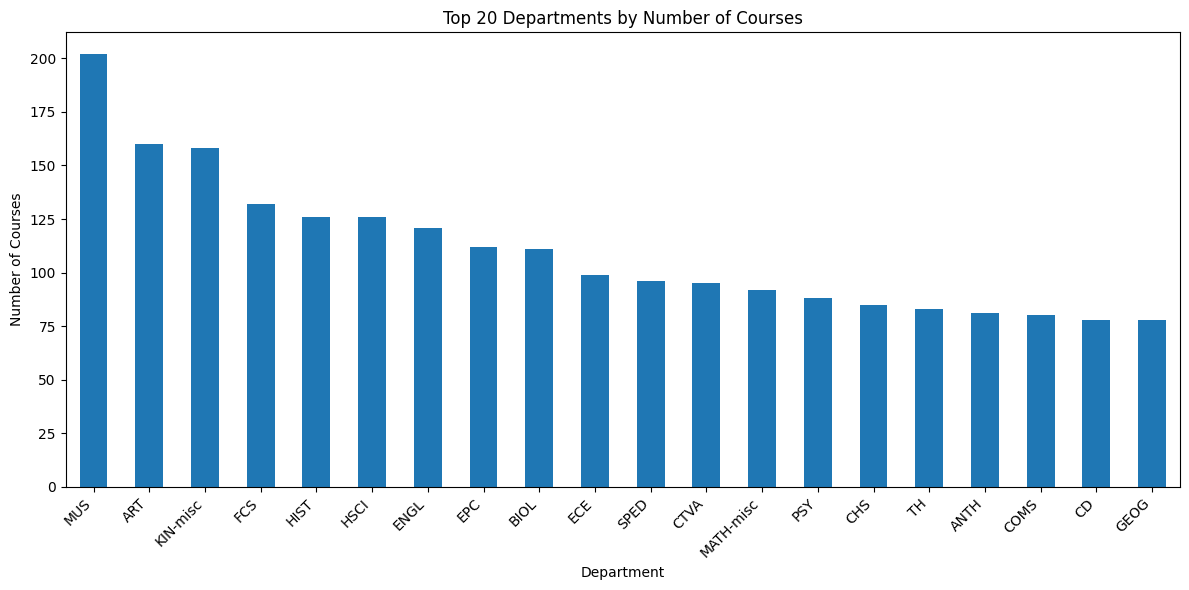

In [22]:
courses_per_dept = courses_df['department'].value_counts().sort_values(ascending=False)

print("Number of Courses per Department:\n")
print(courses_per_dept.head(10).to_markdown(numalign="left", stralign="left"))
print("\n")
print(courses_per_dept.tail(10).to_markdown(numalign="left", stralign="left"))

plt.figure(figsize=(12, 6))
courses_per_dept.head(20).plot(kind='bar')
plt.title('Top 20 Departments by Number of Courses')
plt.xlabel('Department')
plt.ylabel('Number of Courses')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**The bar graph is showing the top 20 departments that has the most courses. I did not expect Music and Art to be in the top two especially music having 200 courses in the department but it does make sense since there are many different instruments and forms of art as well as levels of music and the kind of music.**

Most Offered Subjects:

| subject   | count   |
|:----------|:--------|
| MUS       | 202     |
| ART       | 160     |
| KIN       | 158     |
| FCS       | 132     |
| HSCI      | 126     |
| HIST      | 126     |
| ENGL      | 121     |
| EPC       | 112     |
| BIOL      | 111     |
| ECE       | 99      |

Least Offered Subjects:

| subject   | count   |
|:----------|:--------|
| CECS      | 2       |
| ATHL      | 2       |
| KOR       | 2       |
| HEBR      | 2       |
| MEIS      | 1       |
| HUMN      | 1       |
| SBS       | 1       |
| PHSC      | 1       |
| LEAD      | 1       |
| LIB       | 1       |


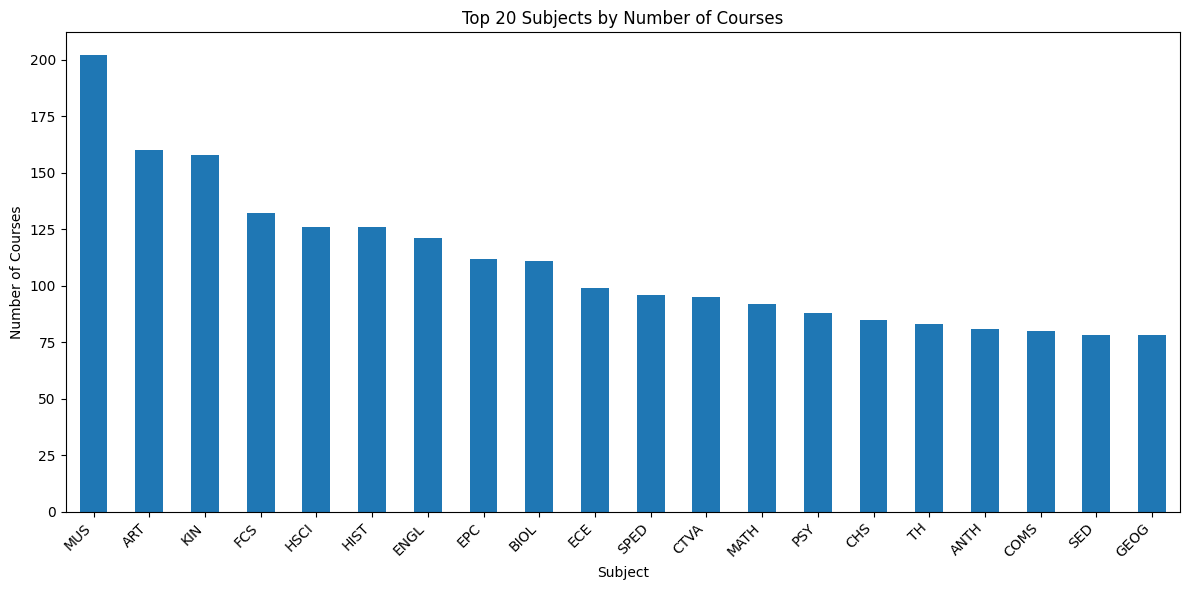

In [23]:
courses_df['subject'] = courses_df['course_title'].apply(lambda x: x.split(' ')[0] if ' ' in x else x)

subject_counts = courses_df['subject'].value_counts().sort_values(ascending=False)

print("Most Offered Subjects:\n")
print(subject_counts.head(10).to_markdown(numalign="left", stralign="left"))

print("\nLeast Offered Subjects:\n")
print(subject_counts.tail(10).to_markdown(numalign="left", stralign="left"))

plt.figure(figsize=(12, 6))
subject_counts.head(20).plot(kind='bar')
plt.title('Top 20 Subjects by Number of Courses')
plt.xlabel('Subject')
plt.ylabel('Number of Courses')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##SQL and GitHub

In [24]:
import sqlite3
import pandas as pd

db_name = 'csun_course.db'

conn = sqlite3.connect(db_name)

courses_df.to_sql('courses', conn, if_exists='replace', index=False)

conn.close()

print(f"Data successfully saved to '{db_name}' in a table named 'courses'.")

Data successfully saved to 'csun_course.db' in a table named 'courses'.


In [25]:
from google.colab import files
files.download('csun_course.db')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**SQL was the hardest part for me as I did not know if I even did it correctly or finished what it is I needed to do.**